### Real-Time Violence Detection — CCTV Surveillance

## Background & Description

### What is this notebook?
This notebook trains and deploys a real-time anomaly detection system for CCTV footage. Using the **UCF Crime Dataset**, it classifies live video streams into four actionable categories:
- **Normal** — routine, uneventful activity
- **Theft** — shoplifting, robbery, burglary, stealing
- **Violence** — assault, fighting, abuse, shooting
- **Property damage** — arson, vandalism, and similar acts

---

### Key Definitions

**UCF Crime Dataset** — A large collection of real-world surveillance camera footage labeled with fine-grained crime categories, used here as the training data source.

**CLAHE (Contrast Limited Adaptive Histogram Equalization)** — An image processing technique that enhances local contrast. It operates in LAB colorspace to brighten dark CCTV footage without distorting colors.

**YOLOv8 (You Only Look Once)** — A fast object detection model used here to detect people and crop the frame tightly around them, focusing the model on human activity rather than background noise.

**Motion Frame Selection** — A technique that scores frames by pixel-level differences. The 16 frames with the highest motion scores are selected to capture the heart of the action within a window.

**ResNet50** — A deep convolutional network acting as a feature extractor. It converts a 224x224 image into a 2048-dimensional vector describing the visual content.

**BiLSTM (Bidirectional Long Short-Term Memory)** — A recurrent neural network that processes sequences forward and backward. It learns temporal patterns, like the specific motion signature of a physical altercation.

**Class Weights** — Mathematical multipliers applied during training to balance the dataset. They ensure the model pays extra attention to rare categories (like "Theft") instead of just defaulting to the most common label.

**L2 Regularization** — A penalty that prevents the model from becoming overly complex, forcing it to learn general patterns that work across different camera angles and lighting conditions.

**Dropout** — A technique that randomly deactivates neurons during training to prevent "memorization" and encourage the network to find robust, independent features.

**Temporal Smoothing** — A post-prediction filter that requires a label to maintain a consistent confidence score (e.g., >0.65) across multiple consecutive windows before triggering an alert.

---

### The Pipeline

#### 1. Data Preparation
- The dataset is filtered to the four target categories; irrelevant classes like `explosion` or `roadaccidents` are dropped.
- Class weights are calculated to compensate for the higher frequency of "Normal" videos.

#### 2. Frame Preprocessing
Every video passes through a standardized pipeline:
- **CLAHE** corrects for uneven surveillance lighting.
- **YOLOv8** crops the frame to the densest cluster of human activity with a 15-20% buffer for context.
- Frames are resized to 224x224 and converted to RGB.

#### 3. Motion-Based Sampling
- A 64-frame sliding window is sampled (matching the live inference buffer).
- The top 16 motion-heavy frames are extracted to eliminate static footage where no action is occurring.
- This process is repeated 5 times per video to augment the training data.

#### 4. Feature Extraction & Training
- Selected frames pass through **ResNet50** to create a (16, 2048) sequence.
- These sequences feed into the **BiLSTM** with dropout and L2 regularization.
- The model uses **Categorical Cross-Entropy** and **Early Stopping** to optimize for accuracy without overfitting.

#### 5. Live Inference & Thresholding
- **Rolling Buffer:** Frames are stored in a 64-frame deque. Every 8 frames, a snapshot is taken for analysis.
- **Daemon Threading:** Processing (YOLO + ResNet + BiLSTM) happens in a background thread to keep the video display fluid and real-time.
- **Smoothing & Voting:** Raw predictions must clear a confidence threshold. A **Majority Vote** across smoothed results determines the final classification for the entire clip.
  

In [31]:
# Install required packages: MediaPipe (pose estimation), Decord (fast video decoding), Ultralytics (YOLOv8 detection)
!pip install mediapipe decord ultralytics -q

# Mixed precision training — runs float16 ops for speed while keeping float32 weights for stability
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# ── Imports ───────────────────────────────────────────────────────────────────
import os
import cv2
import pickle
import random
import threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

# Sklearn utilities for splitting data, evaluation metrics, and class imbalance handling
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

from tqdm.auto import tqdm
from IPython.display import Video, display
from collections import deque, Counter  # deque/Counter used in sliding window inference logic

# PyTorch (YOLO backend), MediaPipe (pose landmarks), Decord (fast frame decoding), YOLO (person detection)
import torch
import mediapipe as mp
from decord import VideoReader, cpu
from ultralytics import YOLO

# ── Environment check — verify GPU access before proceeding ──────────────────
print(f"TF  version : {tf.__version__}")
print(f"GPU (torch) : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name    : {torch.cuda.get_device_name(0)}")
print(f"TF GPUs     : {tf.config.list_physical_devices('GPU')}")

TF  version : 2.19.0
GPU (torch) : True
GPU name    : Tesla P100-PCIE-16GB
TF GPUs     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [32]:
# ── Dataset Setup ─────────────────────────────────────────────────────────────
# UCF Crime dataset root — contains per-class subfolders and train/test CSVs
root_path   = "/kaggle/input/real-time-anomaly-detection-in-cctv-surveillance/data/"
folder_list = os.listdir(root_path)

# Extract class label names by filtering out CSV files from the directory listing
label_list  = [p for p in folder_list if not p.endswith(".csv")]

# Load train/test splits and build a unified label lookup (label + video_name)
train_df  = pd.read_csv(root_path + 'train.csv')
test_df   = pd.read_csv(root_path + 'test.csv')
labels_df = pd.concat([train_df, test_df])[['label', 'video_name']]
labels_df

,label,video_name
0,normal,data\normal\Normal_Videos_196_x264.mp4
1,normal,data\normal\Normal_Videos179_x264.mp4
2,normal,data\normal\Normal_Videos361_x264.mp4
3,roadaccidents,data\roadaccidents\RoadAccidents017_x264.mp4
4,normal,data\normal\Normal_Videos125_x264.mp4
...,...,...
375,roadaccidents,data\roadaccidents\RoadAccidents025_x264.mp4
376,stealing,data\stealing\Stealing104_x264.mp4
377,stealing,data\stealing\Stealing036_x264.mp4
378,vandalism,data\vandalism\Vandalism045_x264.mp4


In [33]:
# ── Label Filtering & Path Construction ───────────────────────────────────────
# Drop categories that aren't relevant to core surveillance threat detection
labels_df = labels_df[
    ~labels_df['label'].isin(['explosion', 'arrest', 'roadaccidents'])
].dropna().copy()

# Normalize video filenames (fix Windows backslashes) and build absolute file paths
PREFIX = '/kaggle/input/real-time-anomaly-detection-in-cctv-surveillance/data/'
labels_df['video_name'] = (labels_df['video_name']
                           .str.replace('\\', '/', regex=False)
                           .str.split('/').str[-1])
labels_df['full_path'] = PREFIX + labels_df['label'] + '/' + labels_df['video_name']

# ── Label Consolidation ───────────────────────────────────────────────────────
# Collapse the original fine-grained UCF Crime classes into 4 broader categories
# to reduce class imbalance and simplify the classification task.
#   theft           → shoplifting, stealing, burglary, robbery
#   violence        → abuse, assault, fighting, shooting
#   normal          → normal (no incident)
#   property_damage → anything else remaining
def label_mapping(lv):
    if lv in ['shoplifting', 'stealing', 'burglary', 'robbery']:
        return 'theft'
    if lv in ['abuse', 'assault', 'fighting', 'shooting']:
        return 'violence'
    if lv == 'normal':
        return 'normal'
    return 'property_damage'

labels_df['label'] = labels_df['label'].apply(label_mapping)
labels_df

,label,video_name,full_path
0,normal,Normal_Videos_196_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
1,normal,Normal_Videos179_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
2,normal,Normal_Videos361_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
4,normal,Normal_Videos125_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
5,normal,Normal_Videos160_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
...,...,...,...
374,property_damage,Arson049_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
376,theft,Stealing104_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
377,theft,Stealing036_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
378,property_damage,Vandalism045_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...


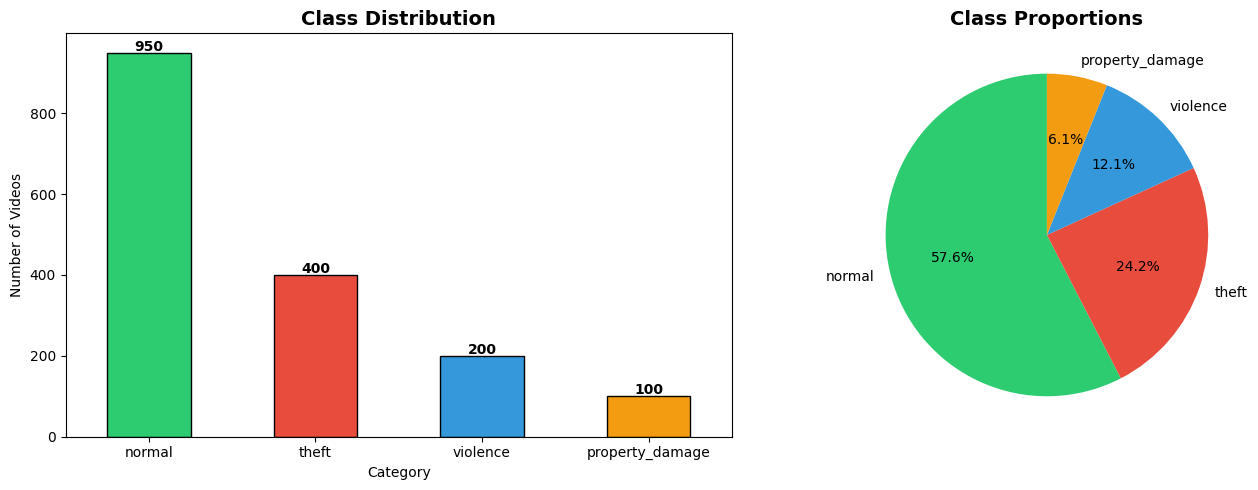

Total videos           : 1650
Class balance (min/max): 0.11


In [34]:
# ── Class Distribution Visualization ─────────────────────────────────────────
# Bar + pie chart of the 4 consolidated labels to assess class imbalance
# before deciding on sampling strategy or loss weighting during training.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = labels_df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Number of Videos')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout(); plt.show()

# Min/max ratio — values close to 1.0 indicate a balanced dataset
print(f"Total videos           : {len(labels_df)}")
print(f"Class balance (min/max): {counts.min()/counts.max():.2f}")

In [35]:
# ── Person Detection & Frame Preprocessing ────────────────────────────────────
# YOLOv8n is used to isolate people in each frame before classification.
# Keeping the same preprocessing pipeline for both training and inference
# ensures the model never sees a different frame distribution at runtime.
yolo_model = YOLO('yolov8n.pt')


def get_densest_cluster_coords(frame_shape, people_bboxes):
    """
    Given multiple detected person bboxes, find the densest spatial cluster
    and return padded crop coordinates around it. Prevents the model from
    focusing on a bystander in the background instead of the main incident.
    """
    bboxes  = np.array(people_bboxes)
    centers = bboxes[:, :2] + bboxes[:, 2:] / 2.0
    h_f, w_f = frame_shape[:2]
    threshold = 0.3 * np.sqrt(h_f**2 + w_f**2)
    diff = centers[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist_matrix = np.linalg.norm(diff, axis=2)
    densest_idx = np.argmax(np.sum(dist_matrix < threshold, axis=1))
    cluster = bboxes[dist_matrix[densest_idx] < threshold]
    x1 = np.min(cluster[:, 0]);  y1 = np.min(cluster[:, 1])
    x2 = np.max(cluster[:, 0] + cluster[:, 2])
    y2 = np.max(cluster[:, 1] + cluster[:, 3])
    pad = 0.15
    w_c, h_c = x2 - x1, y2 - y1
    return (int(max(0, x1 - w_c*pad)), int(max(0, y1 - h_c*pad)),
            int(min(w_f, x2 + w_c*pad)), int(min(h_f, y2 + h_c*pad)))


def crop_to_people(frame_bgr):
    """
    Run YOLOv8 person detection and crop the frame to the relevant region.
    Falls back to the original frame if no people are detected.
    """
    results = yolo_model.predict(frame_bgr, classes=[0], conf=0.4, verbose=False, imgsz=640)[0]
    boxes = results.boxes.xywh.cpu().numpy()
    if len(boxes) == 0:
        return frame_bgr
    people_bboxes = [[b[0] - b[2]/2, b[1] - b[3]/2, b[2], b[3]] for b in boxes]
    if len(people_bboxes) == 1:
        x, y, w, h = people_bboxes[0]
        p = 0.2
        x1 = int(max(0, x - w*p));  y1 = int(max(0, y - h*p))
        x2 = int(min(frame_bgr.shape[1], x + w + w*p))
        y2 = int(min(frame_bgr.shape[0], y + h + h*p))
    else:
        x1, y1, x2, y2 = get_densest_cluster_coords(frame_bgr.shape, people_bboxes)
    cropped = frame_bgr[y1:y2, x1:x2]
    return cropped if cropped.size > 0 else frame_bgr


def apply_clahe(frame_bgr):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) in LAB
    colorspace to improve visibility in dark or low-contrast CCTV footage.
    """
    lab = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)


# ── Unified frame preprocessor — used identically during training AND inference
def preprocess_frame(frame_bgr):
    """CLAHE contrast enhancement → YOLO person crop → resize 224×224 → RGB."""
    frame_bgr = apply_clahe(frame_bgr)
    frame_bgr = crop_to_people(frame_bgr)
    frame_bgr = cv2.resize(frame_bgr, (224, 224))
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


print("YOLO + CLAHE utilities ready.")

YOLO + CLAHE utilities ready.


In [36]:
# ── Feature Extractor ─────────────────────────────────────────────────────────
# ResNet50 pretrained on ImageNet — used as a frozen CNN backbone to extract
# 2048-dim feature vectors from each preprocessed frame. The top classification
# layer is excluded since we supply our own classifier head.
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print("ResNet50 loaded. Output shape per frame: (2048,)")

ResNet50 loaded. Output shape per frame: (2048,)


In [37]:
# ── Motion-Based Frame Selection ──────────────────────────────────────────────
# Rather than sampling frames uniformly, we prioritize frames with the most
# inter-frame motion. This ensures the model sees action-rich content instead
# of static background frames, which is critical for distinguishing anomalies
# from normal footage in the UCF Crime dataset.

def select_motion_from_array(frames, sequence_length=16):
    """
    Select the `sequence_length` highest-motion frames from a numpy array
    by ranking frames on absolute grayscale difference from the prior frame.

    frames : (N, H, W, 3) RGB numpy array
    Returns: (sequence_length, H, W, 3) numpy array
    """
    n = len(frames)
    if n <= sequence_length:
        result = list(frames)
        while len(result) < sequence_length:
            result.append(frames[-1])
        return np.array(result)

    # Compute per-frame motion scores on GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    t = torch.from_numpy(frames).float().to(device)
    gray = 0.299*t[:,:,:,0] + 0.587*t[:,:,:,1] + 0.114*t[:,:,:,2]
    scores = torch.sum(torch.abs(gray[1:] - gray[:-1]), dim=(1, 2)).cpu().numpy()

    top_rel = np.argsort(scores)[-sequence_length:]
    indices = sorted([int(i) + 1 for i in top_rel if int(i) + 1 < n])
    while len(indices) < sequence_length:
        indices.append(indices[-1] if indices else n - 1)
    return frames[indices[:sequence_length]]


def get_window_frames(video_path, window_size=64, sequence_length=16):
    """
    Sample a random window of `window_size` frames from the video, then
    select the top `sequence_length` motion frames within that window.

    Mirrors the live rolling buffer used at inference time — keeping training
    and runtime sampling consistent is important for model generalization.

    Returns: (sequence_length, H, W, 3) RGB numpy array, or None on failure.
    """
    try:
        vr    = VideoReader(video_path, ctx=cpu(0))
        total = len(vr)
        if total < 2:
            return None
        if total <= window_size:
            window_indices = list(range(total))
        else:
            start = random.randint(0, total - window_size)
            window_indices = list(range(start, start + window_size))

        frames = vr.get_batch(window_indices).asnumpy()   # RGB
        return select_motion_from_array(frames, sequence_length)
    except Exception as e:
        print(f'[window error] {video_path}: {e}')
        return None


print("Motion frame utilities ready.")

Motion frame utilities ready.


In [41]:
# ── Feature Extraction Config ─────────────────────────────────────────────────
# Minority classes get more windows per video to compensate for class imbalance.
# Each window is an independent temporal sample, so this acts as oversampling.
CLASS_WINDOWS = {
    'normal':          5,
    'theft':           8,
    'violence':        12,
    'property_damage': 15,
}
WINDOW_SIZE = 64   # frames sampled per window before motion selection
SEQ_LEN     = 16   # top-motion frames kept per window

# Output directory for extracted feature arrays (.pkl per video)
output_dir = '/kaggle/working/processed_motion_frames'
os.makedirs(output_dir, exist_ok=True)

# ── Feature Extraction Loop ───────────────────────────────────────────────────
# For each video: sample n_windows temporal windows, preprocess each frame
# (CLAHE → YOLO crop → resize), then extract 2048-dim ResNet50 features.
# Saves shape (n_windows, SEQ_LEN, 2048) per video as a .pkl file.
# Existing files with the correct shape are skipped to allow safe resume.
pbar = tqdm(labels_df.iterrows(), total=len(labels_df), desc="Extracting features")
for idx, row in pbar:
    video_path  = row['full_path']
    video_name  = row['video_name']
    label       = row['label']
    safe_name   = video_name.replace('.mp4', '.pkl')
    output_path = os.path.join(output_dir, safe_name)
    pbar.set_postfix(file=video_name[-22:], label=label)

    n_windows = CLASS_WINDOWS[label]

    # Skip if a valid file with the expected number of windows already exists
    if os.path.exists(output_path):
        try:
            with open(output_path, 'rb') as f:
                existing = pickle.load(f)
            if (isinstance(existing, np.ndarray)
                    and existing.ndim == 3
                    and existing.shape[0] == n_windows):
                continue
        except Exception:
            pass  # corrupted file — re-extract

    all_features = []
    for _ in range(n_windows):
        raw_frames = get_window_frames(video_path, WINDOW_SIZE, SEQ_LEN)
        if raw_frames is None:
            continue

        # Preprocess each frame and stack into a batch for ResNet50
        processed = []
        for frame_rgb in raw_frames:
            frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
            rgb_224   = preprocess_frame(frame_bgr)
            processed.append(rgb_224)

        frames_array = np.array(processed, dtype='float32')
        features     = base_model.predict(
                           preprocess_input(frames_array), verbose=0)
        all_features.append(features)

    if all_features:
        with open(output_path, 'wb') as f:
            pickle.dump(np.array(all_features, dtype='float32'), f)

# ── Extraction Verification ───────────────────────────────────────────────────
# Count total extracted windows per class and inspect a sample file shape.
# Expected shape per file: (n_windows, SEQ_LEN, 2048)
print("\nExtraction complete. Verifying class distribution...\n")
class_counts = {k: 0 for k in CLASS_WINDOWS}
for idx, row in labels_df.iterrows():
    safe_name   = row['video_name'].replace('.mp4', '.pkl')
    output_path = os.path.join(output_dir, safe_name)
    if os.path.exists(output_path):
        with open(output_path, 'rb') as f:
            feat = pickle.load(f)
        class_counts[row['label']] += feat.shape[0]

print("Estimated training samples per class (before train/val/test split):")
for cls, count in class_counts.items():
    print(f"  {cls:20s}: {count} windows")

sample_file = os.path.join(output_dir, os.listdir(output_dir)[0])
sample_feat = pickle.load(open(sample_file, 'rb'))
print(f"\nSample file    : {os.path.basename(sample_file)}")
print(f"Shape          : {sample_feat.shape}")

Extracting features:   0%|          | 0/1650 [00:00<?, ?it/s]


Extraction complete. Verifying class distribution...

Estimated training samples per class (before train/val/test split):
  normal              : 4750 windows
  theft               : 3200 windows
  violence            : 2400 windows
  property_damage     : 1500 windows

Sample file    : Normal_Videos664_x264.pkl
Shape          : (5, 16, 2048)


In [42]:
# ── Class Weights ─────────────────────────────────────────────────────────────
# Manually tuned weights passed to the loss function during training to further
# counteract class imbalance beyond what window oversampling alone achieves.
# Normal footage is downweighted since it dominates the dataset; property_damage
# is aggressively upweighted as the rarest and most critical class to detect.
class_weight_dict = {
    0: 0.3,   # normal
    1: 0.8,   # theft
    2: 1.5,   # violence
    3: 3.0,   # property_damage
}

print("Manual class weights:")
for i, (label, weight) in enumerate(zip(['normal', 'theft', 'violence', 'property_damage'], class_weight_dict.values())):
    print(f"  {label:20s}: {weight}")

Manual class weights:
  normal              : 0.3
  theft               : 0.8
  violence            : 1.5
  property_damage     : 3.0


In [43]:
# ── Dataset Assembly & Train/Val/Test Split ───────────────────────────────────
from tqdm import tqdm

# Label mappings used throughout training and evaluation
label2id = {'normal': 0, 'theft': 1, 'violence': 2, 'property_damage': 3}
id2label = {v: k for k, v in label2id.items()}

X, y = [], []
FEAT_DIR = '/kaggle/working/processed_motion_frames'

# Load all extracted .pkl feature files and flatten windows into individual samples
for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Loading features"):
    safe_name = row['video_name'].replace('.mp4', '.pkl')
    feat_path = os.path.join(FEAT_DIR, safe_name)
    if not os.path.exists(feat_path):
        continue
    with open(feat_path, 'rb') as f:
        feat = pickle.load(f)

    # Support both new (n_windows, 16, 2048) and legacy (16, 2048) file shapes
    if feat.ndim == 2:
        feat = feat[np.newaxis, ...]
    for window_feat in feat:
        if window_feat.shape == (16, 2048):
            X.append(window_feat)
            y.append(label2id[row['label']])

X = np.array(X, dtype='float32')
y = np.array(y)
print(f"Dataset: X={X.shape}, y={y.shape}")
print(f"Samples per class: {dict(zip(*np.unique(y, return_counts=True)))}")

# Stratified 70/15/15 split — stratify ensures class proportions are preserved
# across all three splits, which matters given the imbala

Loading features: 100%|██████████| 1650/1650 [00:07<00:00, 222.66it/s]


Dataset: X=(11850, 16, 2048), y=(11850,)
Samples per class: {np.int64(0): np.int64(4750), np.int64(1): np.int64(3200), np.int64(2): np.int64(2400), np.int64(3): np.int64(1500)}
Train: 8295  Val: 1777  Test: 1778


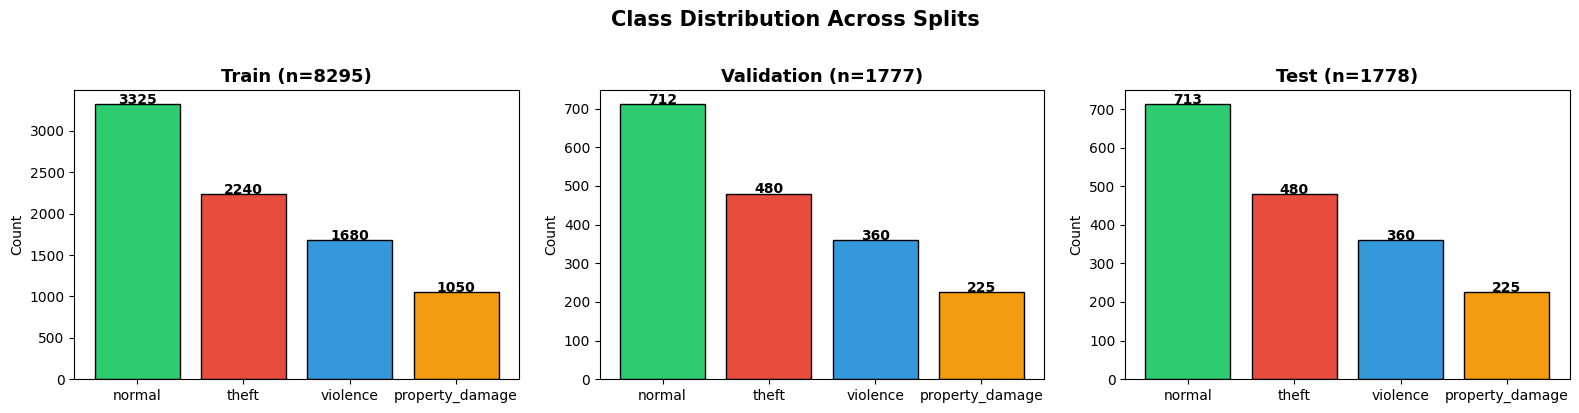

In [44]:
# ── Split Distribution Visualization ─────────────────────────────────────────
# Verify that stratified splitting preserved class proportions across all three
# splits — bars should look roughly proportional between Train, Val, and Test.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
split_names  = ['Train', 'Validation', 'Test']
split_labels = [y_train, y_val, y_test]
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for ax, name, lbls in zip(axes, split_names, split_labels):
    unique, cnts = np.unique(lbls, return_counts=True)
    class_names  = [id2label[u] for u in unique]
    ax.bar(class_names, cnts, color=colors, edgecolor='black')
    ax.set_title(f'{name} (n={len(lbls)})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(cnts):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Class Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [45]:
# ── Class Weights (sklearn balanced) ─────────────────────────────────────────
# Recompute weights from the training split to complement manual oversampling.
weights_arr = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights_arr))
print(f"Class weights: {class_weight_dict}")


# ── BiLSTM Classifier ─────────────────────────────────────────────────────────
# Takes a sequence of 16 ResNet50 feature vectors (2048-dim each) and classifies
# the window into one of 4 categories. BiLSTM captures temporal context in both
# directions; GlobalAveragePooling1D collapses the sequence before the head.
def build_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(16, 2048)),
        layers.Bidirectional(layers.LSTM(64, dropout=0.5, return_sequences=True)),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(len(label2id), activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


# Clear any leftover graph state before building to avoid memory leaks
import gc
gc.collect()
tf.keras.backend.clear_session()

lstm_model = build_model()
lstm_model.summary()

# ── Training Callbacks ────────────────────────────────────────────────────────
# ReduceLROnPlateau: halves LR if val_loss stalls, down to a 1e-6 floor.
# EarlyStopping: halts training and restores best weights if val_loss stops improving.
# EpochLogger: lightweight console logging every 10 epochs (verbose=0 otherwise).
reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                          patience=3, min_lr=1e-6, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                      restore_best_weights=True)

class EpochLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}: "
                  f"loss={logs['loss']:.4f}  "
                  f"val_loss={logs['val_loss']:.4f}  "
                  f"val_acc={logs['val_accuracy']:.4f}")

# ── Training ──────────────────────────────────────────────────────────────────
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, EpochLogger()],
    verbose=0,
)

Class weights: {0: np.float64(0.6236842105263158), 1: np.float64(0.92578125), 2: np.float64(1.234375), 3: np.float64(1.975)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 16, 128)        │     1,081,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,372 (4.16 MB)

 Trainable params: 1,090,372 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch  10: loss=1.0719  val_loss=0.9768  val_acc=0.7107
Epoch  20: loss=0.7274  val_loss=0.6615  val_acc=0.8075
Epoch  30: loss=0.4991  val_loss=0.5128  val_acc=0.8559

Epoch 40: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
Epoch  40: loss=0.3742  val_loss=0.4237  val_acc=0.8875

Epoch 47: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
Epoch  50: loss=0.3267  val_loss=0.3905  val_acc=0.9015

Epoch 57: ReduceLROnPlateau reducing learning rate to 1e-06.
Epoch  60: loss=0.3176  val_loss=0.3847  val_acc=0.9015
Epoch  70: loss=0.3195  val_loss=0.3837  val_acc=0.9038
Epoch  80: loss=0.3204  val_loss=0.3828  val_acc=0.9038
Epoch  90: loss=0.3151  val_loss=0.3818  val_acc=0.9010


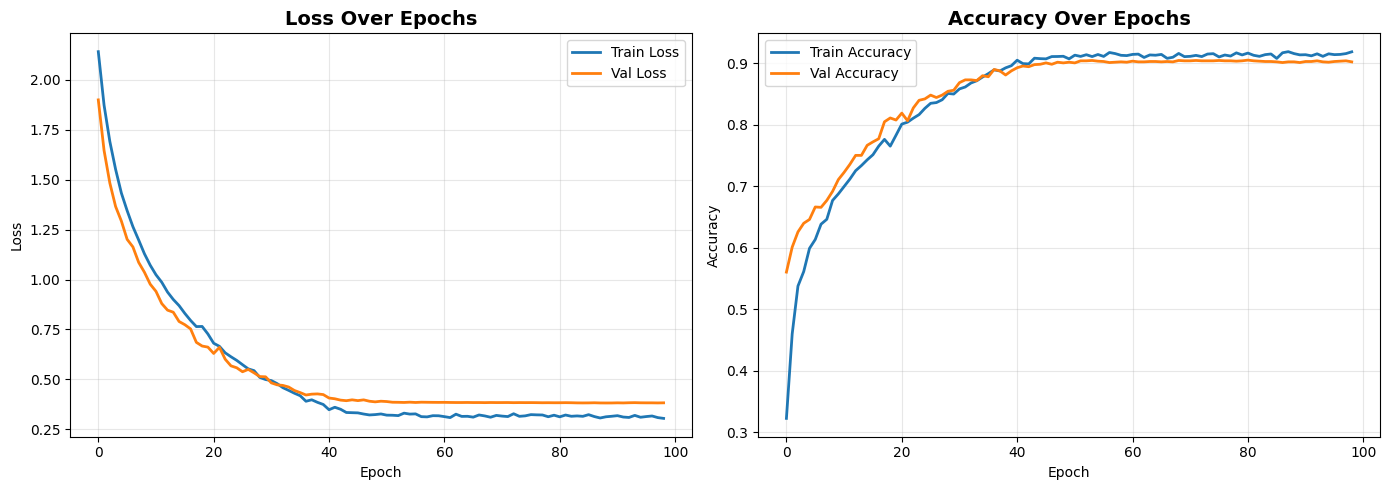

Best epoch    : 89
Val Loss      : 0.3817
Val Accuracy  : 0.9021


In [46]:
# ── Training Curves ───────────────────────────────────────────────────────────
# Plot loss and accuracy over epochs for both train and validation sets.
# Diverging curves indicate overfitting; use this to assess whether early
# stopping triggered at a reasonable point.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Best epoch is determined by minimum val_loss (aligns with EarlyStopping monitor)
best_epoch = np.argmin(history.history['val_loss'])
print(f"Best epoch    : {best_epoch + 1}")
print(f"Val Loss      : {history.history['val_loss'][best_epoch]:.4f}")
print(f"Val Accuracy  : {history.history['val_accuracy'][best_epoch]:.4f}")

In [47]:
# ── Test Set Evaluation ───────────────────────────────────────────────────────
# Final evaluation on the held-out test split using the best checkpoint
# restored by EarlyStopping. Per-class precision/recall/F1 in the
# classification report highlights which categories the model struggles with.
eval_labels = ['normal', 'theft', 'violence', 'property_damage']

print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

test_loss, test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

y_pred_probs = lstm_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=eval_labels, digits=4))

TEST SET EVALUATION

Test Accuracy : 88.70%
Test Loss     : 0.3889

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

         normal     0.9495    0.8710    0.9086       713
          theft     0.8350    0.8750    0.8545       480
       violence     0.8586    0.9111    0.8841       360
property_damage     0.8703    0.9244    0.8966       225

       accuracy                         0.8870      1778
      macro avg     0.8784    0.8954    0.8859      1778
   weighted avg     0.8902    0.8870    0.8875      1778



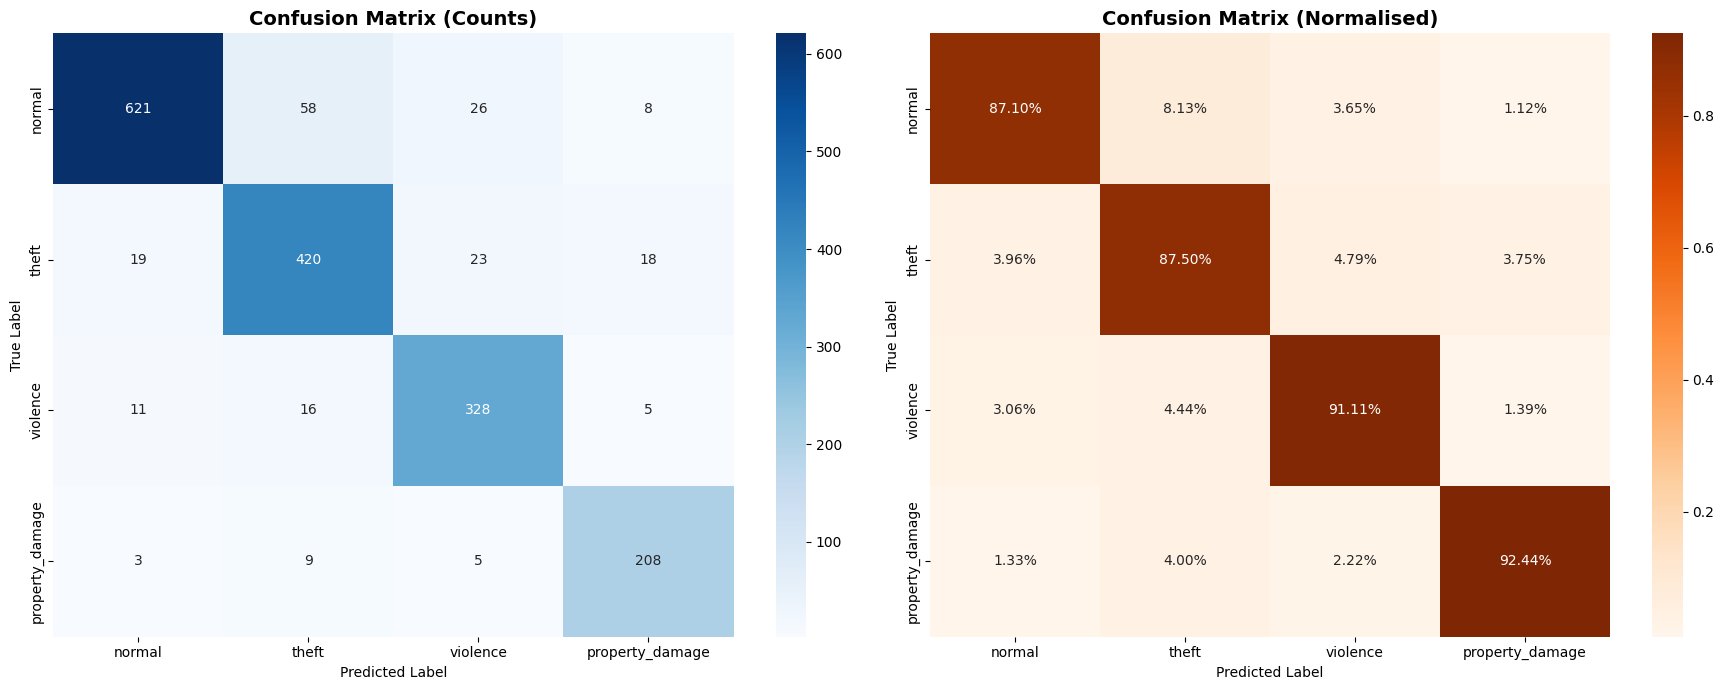

In [48]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
# Raw counts (left) show absolute errors; normalized (right) shows per-class
# recall, making it easier to spot which classes are most confused with each other.
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=eval_labels, yticklabels=eval_labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)',     fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=eval_labels, yticklabels=eval_labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout(); plt.show()

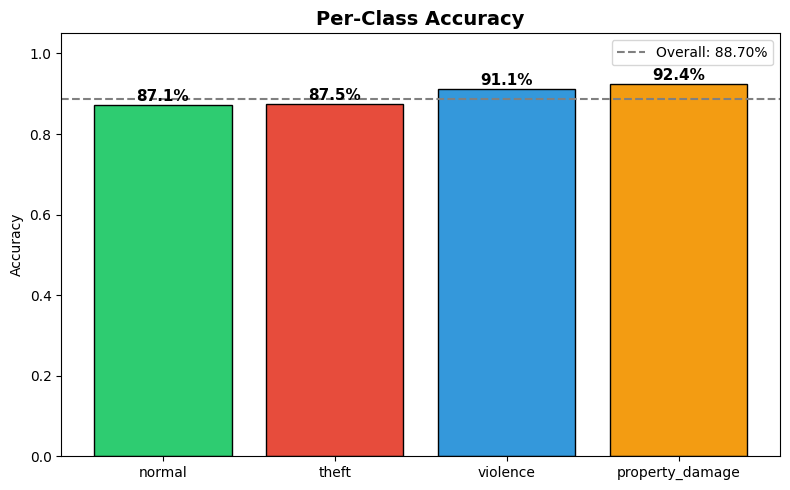

In [49]:
# ── Per-Class Accuracy ────────────────────────────────────────────────────────
# Diagonal of the confusion matrix divided by row sums gives per-class recall.
# The dashed line shows overall accuracy for quick comparison against each class.
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(eval_labels, per_class_acc,
              color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'], edgecolor='black')
ax.axhline(y=test_acc, color='gray', linestyle='--',
           label=f'Overall: {test_acc:.2%}')
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05); ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout(); plt.show()

In [50]:
inv_label_map = {i: name for i, name in enumerate(eval_labels)}

print("=" * 70)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 70 + "\n")

misclassified = np.where(y_test != y_pred)[0]
print(f"Total: {len(misclassified)} / {len(y_test)}\n")

pairs = {}
for i in misclassified:
    pair = (inv_label_map[int(y_test[i])], inv_label_map[int(y_pred[i])])
    pairs[pair] = pairs.get(pair, 0) + 1

for (true_l, pred_l), count in sorted(pairs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {true_l:18s} -> {pred_l:18s}: {count:3d}")

MISCLASSIFICATION ANALYSIS

Total: 201 / 1778

  normal             -> theft             :  58
  normal             -> violence          :  26
  theft              -> violence          :  23
  theft              -> normal            :  19
  theft              -> property_damage   :  18
  violence           -> theft             :  16
  violence           -> normal            :  11
  property_damage    -> theft             :   9
  normal             -> property_damage   :   8
  property_damage    -> violence          :   5
  violence           -> property_damage   :   5
  property_damage    -> normal            :   3


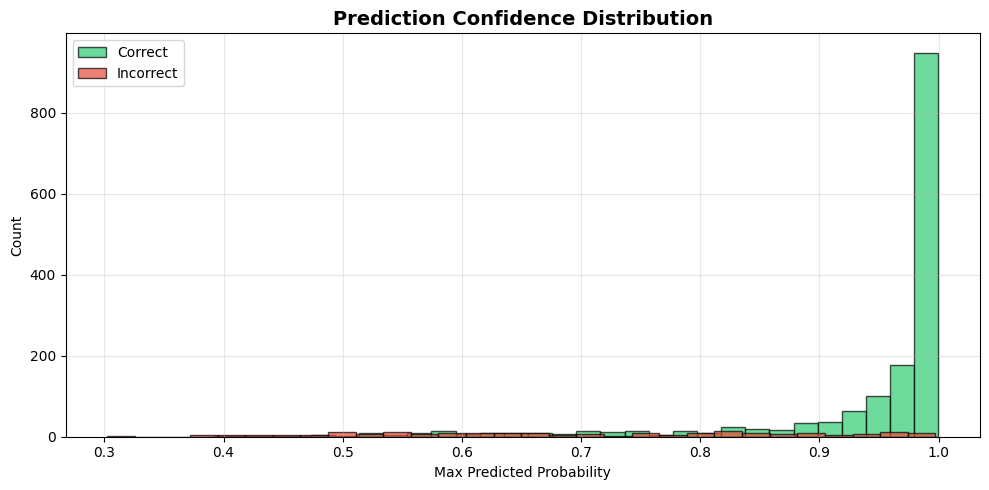

Mean confidence (correct)  : 0.9415
Mean confidence (incorrect): 0.7042


In [51]:
# ── Misclassification Analysis ────────────────────────────────────────────────
# Break down exactly which class pairs are being confused and how often.
# High counts on a specific true→predicted pair may indicate feature overlap
# between those categories or insufficient training samples for that class.
inv_label_map = {i: name for i, name in enumerate(eval_labels)}

print("=" * 70)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 70 + "\n")

misclassified = np.where(y_test != y_pred)[0]
print(f"Total: {len(misclassified)} / {len(y_test)}\n")

# Tally each true→predicted confusion pair and sort by frequency
pairs = {}
for i in misclassified:
    pair = (inv_label_map[int(y_test[i])], inv_label_map[int(y_pred[i])])
    pairs[pair] = pairs.get(pair, 0) + 1

for (true_l, pred_l), count in sorted(pairs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {true_l:18s} -> {pred_l:18s}: {count:3d}")

In [62]:
import os, cv2, time, threading
import numpy as np
from collections import deque, Counter
from IPython.display import display, clear_output, Image
from tensorflow.keras.applications.resnet50 import preprocess_input

# ── Inference Config ──────────────────────────────────────────────────────────
# BUFFER_SIZE: rolling frame buffer fed into motion selection.
# INFER_EVERY_N: run inference once every N frames to avoid blocking the loop.
# CONFIDENCE_THRESHOLD: retained for optional future gating (currently unused).
BUFFER_SIZE          = 64
SEQUENCE_LENGTH      = 16
INFER_EVERY_N        = 8
CONFIDENCE_THRESHOLD = 0.65

# Global state shared between the capture loop and inference thread
frame_buffer      = deque(maxlen=BUFFER_SIZE)
inference_state   = {'label': 'buffering...', 'conf': 0.0, 'lock': threading.Lock()}
predictions       = []
prediction_window = deque(maxlen=5)

# BGR overlay colors per predicted class
LABEL_COLORS_BGR = {
    'violence':        (0,   0, 255),
    'non-violence':    (0, 200,   0),
    'normal':          (0, 200,   0),
    'theft':           (0, 165, 255),
    'property_damage': (0, 165, 255),
    'buffering...':    (180, 180, 180),
}
DEFAULT_COLOR = (255, 255, 0)


def get_smoothed_label(new_label, new_conf):
    """
    Accumulate confidence scores across a rolling window of the last 5
    predictions and return the highest-scoring label. This reduces flickering
    from single-frame mispredictions without introducing an 'uncertain' state.
    """
    prediction_window.append((new_label, new_conf))
    scores = {}
    for label, conf in prediction_window:
        scores[label] = scores.get(label, 0.0) + conf
    return max(scores, key=scores.get)


def select_motion_frames(buffer):
    """Convert the deque buffer to an array and delegate to motion selector."""
    frames = np.array(list(buffer))
    return select_motion_from_array(frames, SEQUENCE_LENGTH)


def run_inference(selected_rgb):
    """
    Preprocessing and model inference run in a background thread to avoid
    blocking the capture loop. Writes the smoothed result back to
    inference_state under a lock so the main thread can read it safely.
    """
    try:
        prepped = np.array(
            [preprocess_frame(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
             for f in selected_rgb],
            dtype='float32'
        )  # (16, 224, 224, 3)

        features = base_model.predict(
            preprocess_input(prepped), verbose=0)[np.newaxis, ...]  # (1, 16, 2048)
        probs    = lstm_model.predict(features, verbose=0)[0]       # (num_classes,)

        pred_id   = int(np.argmax(probs))
        conf      = float(probs[pred_id])
        raw_label = id2label[pred_id]

        smoothed = get_smoothed_label(raw_label, conf)

        with inference_state['lock']:
            inference_state['label'] = smoothed
            inference_state['conf']  = conf

        predictions.append(smoothed)

    except Exception as e:
        print(f'[inference error] {e}')


def run_live_visual(source):
    """
    Main inference loop for a video file or camera stream.

    Each frame is added to a rolling buffer. Every INFER_EVERY_N frames,
    the top-motion frames are selected and passed to a background inference
    thread. The overlay (label banner + confidence bar) is drawn on every
    frame using the most recent thread-safe result and displayed inline
    via Kaggle-compatible JPEG encoding.
    """
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f'Cannot open source: {source}')

    # Reset all global state before processing a new video
    frame_buffer.clear()
    predictions.clear()
    prediction_window.clear()
    with inference_state['lock']:
        inference_state['label'] = 'buffering...'
        inference_state['conf']  = 0.0

    frame_count   = 0
    active_thread = None

    print(f"Processing: {os.path.basename(source)}")

    try:
        while True:
            ret, bgr = cap.read()
            if not ret:
                break

            frame_count += 1
            frame_buffer.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

            # Spawn a new inference thread every INFER_EVERY_N frames,
            # but only if the previous thread has finished to avoid pileup
            if (frame_count % INFER_EVERY_N == 0
                    and len(frame_buffer) >= SEQUENCE_LENGTH
                    and (active_thread is None or not active_thread.is_alive())):

                selected = select_motion_frames(frame_buffer)
                if selected is not None:
                    active_thread = threading.Thread(
                        target=run_inference,
                        args=(selected.copy(),),
                        daemon=True,
                    )
                    active_thread.start()

            # Read latest inference result safely from the shared state
            with inference_state['lock']:
                current_label = inference_state['label']
                current_conf  = inference_state['conf']

            # ── Frame Overlay ─────────────────────────────────────────────────
            frame  = bgr.copy()
            h, w   = frame.shape[:2]
            color  = LABEL_COLORS_BGR.get(current_label, DEFAULT_COLOR)

            # Semi-transparent top banner background
            overlay = frame.copy()
            cv2.rectangle(overlay, (0, 0), (w, 60), (0, 0, 0), -1)
            cv2.addWeighted(overlay, 0.5, frame, 0.5, 0, frame)

            cv2.putText(frame, f"Prediction: {current_label.upper()}",
                        (12, 38), cv2.FONT_HERSHEY_DUPLEX, 1.0,
                        color, 2, cv2.LINE_AA)

            # Confidence bar (top-right) — fills proportionally to model confidence
            if current_conf > 0:
                bx, by, bw, bh = w - 220, 18, 200, 22
                cv2.rectangle(frame, (bx, by), (bx + bw, by + bh), (60, 60, 60), -1)
                cv2.rectangle(frame, (bx, by),
                              (bx + int(bw * current_conf), by + bh), color, -1)
                cv2.rectangle(frame, (bx, by), (bx + bw, by + bh), (200, 200, 200), 1)
                cv2.putText(frame, f"{current_conf:.0%}",
                            (bx + bw + 6, by + 16),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                            (220, 220, 220), 1, cv2.LINE_AA)

            cv2.putText(frame, f"Frame {frame_count}",
                        (10, h - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (180, 180, 180), 1, cv2.LINE_AA)

            # Encode as JPEG and display inline — required for Kaggle notebooks
            _, encoded = cv2.imencode('.jpg', frame, [cv2.IMWRITE_JPEG_QUALITY, 85])
            clear_output(wait=True)
            display(Image(data=encoded.tobytes()))
            time.sleep(0.01)

    finally:
        if active_thread is not None and active_thread.is_alive():
            print("Waiting for final inference thread...")
            active_thread.join(timeout=15)

        cap.release()

        # ── Summary ───────────────────────────────────────────────────────────
        # Tally all predictions made during the video and report the majority label.
        if predictions:
            counts = Counter(predictions)
            final  = counts.most_common(1)[0][0]
            total  = len(predictions)
            print("\n── RESULTS ───────────────────────────────────────")
            for label, count in counts.most_common():
                bar = '█' * int(count / total * 30)
                print(f"  {label:20s} {count:4d}/{total}  {bar}")
            print(f"\n  FINAL PREDICTION : {final.upper()}")
            print("──────────────────────────────────────────────────")
        else:
            print("No predictions made — video may be too short or below SEQUENCE_LENGTH frames.")

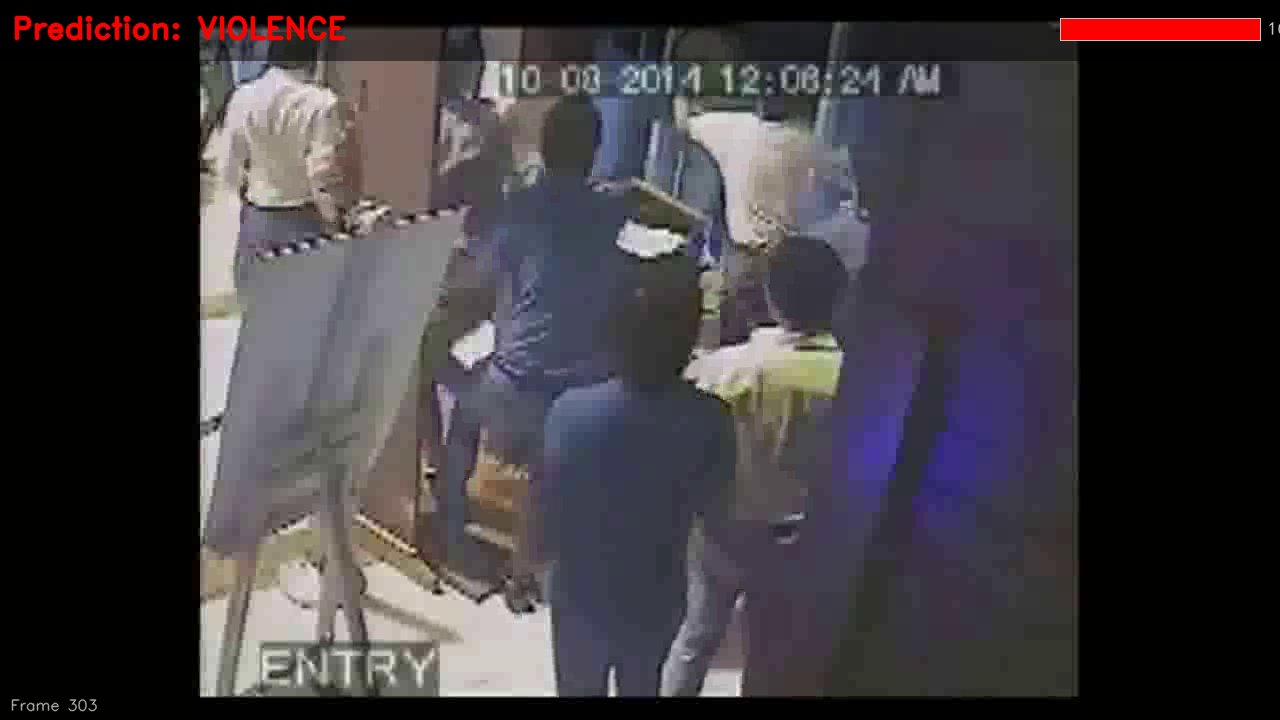

Waiting for final inference thread...

── RESULTS ───────────────────────────────────────
  violence                7/7  ██████████████████████████████

  FINAL PREDICTION : VIOLENCE
──────────────────────────────────────────────────


In [67]:
# ── Run Inference on Test Video ───────────────────────────────────────────────
# Point source at any video file from a different dataset to run the full live pipeline:
# frame buffering → motion selection → ResNet50 + BiLSTM inference → overlay display.
input_video = '/kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted/Test/Violence/t_v009_converted.avi'

if os.path.exists(input_video):
    run_live_visual(source=input_video)
else:
    print("Video file not found.")